## # Prédiction précoce des risques d'inondation à Libreville

**Étudiante :** Eyang Ebona Vanessa
**Encadrant :** Dr Djes-Frésy Bilenga Moukodouma

Ce notebook documente l'ensemble de la démarche de collecte, nettoyage,
exploration et modélisation des données météorologiques utilisées pour
prédire le risque d'inondation à Libreville.

In [1]:
import os
print(os.getcwd())

C:\Users\ADS


## ## Étape 1 : Chargement des données

Les données météorologiques journalières de Libreville (2015-2026) ont été
collectées au préalable via l'API Open-Meteo, puis sauvegardées dans un
fichier CSV. On commence par charger ce fichier et vérifier qu'il est
correctement lu.

In [2]:
# Importation des librairies nécessaires
import pandas as pd            # manipulation de données tabulaires
import matplotlib.pyplot as plt # création de graphiques

# Chargement du fichier CSV contenant les données météo déjà collectées
chemin_fichier = r"C:\Users\ADS\Desktop\Projet_Inondation\donnees_meteo_libreville.csv"
df = pd.read_csv(chemin_fichier, parse_dates=["date"])

# Vérification rapide : nombre de lignes et colonnes chargées
print(f"Nombre de lignes (jours) : {len(df)}")
print(f"Nombre de colonnes (variables) : {len(df.columns)}")

Nombre de lignes (jours) : 4206
Nombre de colonnes (variables) : 15


## ## Étape 2 : Exploration initiale des données

Avant tout traitement, il est indispensable d'inspecter les données :
à quoi ressemblent-elles ? quels types de variables contient-on ?
y a-t-il des valeurs manquantes visibles au premier coup d'œil ?

In [3]:
# Aperçu des 5 premières lignes du tableau de données
df.head()

,date,precipitation_sum,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,pluie_cumul_3j,pluie_cumul_7j,pluie_cumul_15j,humidite_moyenne_7j,amplitude_thermique,risque_proxy_pluviometrique,inondation_reelle
0,2015-01-01,7.6,28.3,23.5,25.2,88,11.5,1009.3,7.6,7.6,7.6,88.000000,4.8,0,0
1,2015-01-02,10.1,28.2,23.2,24.9,88,12.7,1010.0,17.7,17.7,17.7,88.000000,5.0,0,0
2,2015-01-03,7.4,28.1,23.3,24.9,90,10.7,1011.0,25.1,25.1,25.1,88.666667,4.8,0,0
3,2015-01-04,4.4,28.4,23.3,25.6,88,10.5,1010.7,21.9,29.5,29.5,88.500000,5.1,0,0
4,2015-01-05,7.8,27.3,23.8,25.3,90,13.6,1010.0,19.6,37.3,37.3,88.800000,3.5,0,0


In [4]:
# Aperçu des 5 dernières lignes (pour vérifier que les données vont bien
# jusqu'à la date la plus récente)
df.tail()

,date,precipitation_sum,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,pluie_cumul_3j,pluie_cumul_7j,pluie_cumul_15j,humidite_moyenne_7j,amplitude_thermique,risque_proxy_pluviometrique,inondation_reelle
4201,2026-07-03,0.0,27.9,21.9,24.2,75,16.8,1012.5,0.0,0.0,0.8,78.142857,6.0,0,0
4202,2026-07-04,0.0,27.8,21.8,24.2,77,14.2,1012.1,0.0,0.0,0.4,77.857143,6.0,0,0
4203,2026-07-05,0.6,26.0,23.3,24.3,79,15.9,1011.8,0.6,0.6,1.0,78.000000,2.7,0,0
4204,2026-07-06,0.1,26.7,22.1,24.5,78,13.6,1012.9,0.7,0.7,1.0,78.142857,4.6,0,0
4205,2026-07-07,0.0,28.0,22.5,24.7,80,16.7,1013.2,0.7,0.7,1.0,78.142857,5.5,0,0


In [5]:
# Informations générales : nom des colonnes, type de chaque variable,
# et nombre de valeurs non manquantes par colonne
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4206 entries, 0 to 4205
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         4206 non-null   datetime64[ns]
 1   precipitation_sum            4206 non-null   float64       
 2   temperature_2m_max           4206 non-null   float64       
 3   temperature_2m_min           4206 non-null   float64       
 4   temperature_2m_mean          4206 non-null   float64       
 5   relative_humidity_2m_mean    4206 non-null   int64         
 6   wind_speed_10m_max           4206 non-null   float64       
 7   surface_pressure_mean        4206 non-null   float64       
 8   pluie_cumul_3j               4206 non-null   float64       
 9   pluie_cumul_7j               4206 non-null   float64       
 10  pluie_cumul_15j              4206 non-null   float64       
 11  humidite_moyenne_7j          4206 non-null 

In [6]:
# Statistiques descriptives : moyenne, minimum, maximum, écart-type...
# Utile pour repérer d'éventuelles valeurs aberrantes (ex : une température
# de -50°C serait suspecte à Libreville)
df.describe()

,date,precipitation_sum,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,pluie_cumul_3j,pluie_cumul_7j,pluie_cumul_15j,humidite_moyenne_7j,amplitude_thermique,risque_proxy_pluviometrique,inondation_reelle
count,4206,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000,4206.000000
mean,2020-10-03 11:59:59.999999744,7.427936,28.433428,23.975606,25.780932,86.060628,13.709510,1009.259201,22.283785,51.994864,111.416857,86.067752,4.457822,0.087256,0.018069
min,2015-01-01 00:00:00,0.000000,24.700000,20.600000,23.100000,73.000000,6.300000,1004.100000,0.000000,0.000000,0.200000,77.714286,1.000000,0.000000,0.000000
25%,2017-11-17 06:00:00,1.100000,27.600000,23.500000,25.200000,83.000000,11.900000,1008.000000,5.900000,17.900000,45.000000,83.714286,3.800000,0.000000,0.000000
50%,2020-10-03 12:00:00,4.500000,28.400000,24.000000,25.700000,87.000000,13.700000,1009.100000,18.300000,48.800000,112.500000,87.142857,4.500000,0.000000,0.000000
75%,2023-08-20 18:00:00,10.200000,29.200000,24.500000,26.400000,89.000000,15.500000,1010.500000,31.700000,74.475000,158.175000,88.428571,5.100000,0.000000,0.000000
max,2026-07-07 00:00:00,126.500000,32.500000,26.700000,28.300000,96.000000,22.200000,1015.400000,184.900000,261.500000,480.300000,91.714286,9.100000,1.000000,1.000000
std,NaN,9.947046,1.173971,0.784562,0.833050,3.682770,2.579942,1.754181,20.875970,39.520333,75.942239,3.163269,1.001908,0.282244,0.133218


## ## Étape 3 : Nettoyage des données

On vérifie ici trois points essentiels avant toute modélisation :
1. Présence de doublons (même date enregistrée deux fois)
2. Présence de valeurs manquantes (données non renseignées)
3. Cohérence des valeurs (pas de valeurs impossibles ou aberrantes)

In [7]:
# 1. Vérification des doublons
# On vérifie si une même date apparaît plusieurs fois dans le tableau
nb_doublons = df.duplicated(subset=["date"]).sum()
print(f"Nombre de dates en double : {nb_doublons}")

Nombre de dates en double : 0


In [8]:
# 2. Vérification des valeurs manquantes
# Pour chaque colonne, on compte combien de valeurs sont vides (NaN)
valeurs_manquantes = df.isnull().sum()
print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

Nombre de valeurs manquantes par colonne :
date                           0
precipitation_sum              0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
relative_humidity_2m_mean      0
wind_speed_10m_max             0
surface_pressure_mean          0
pluie_cumul_3j                 0
pluie_cumul_7j                 0
pluie_cumul_15j                0
humidite_moyenne_7j            0
amplitude_thermique            0
risque_proxy_pluviometrique    0
inondation_reelle              0
dtype: int64


In [9]:
# 3. Vérification de la cohérence des valeurs
# On regarde les valeurs minimum et maximum de quelques variables clés
# pour détecter d'éventuelles valeurs aberrantes
print("Précipitations - min :", df["precipitation_sum"].min(),
      "- max :", df["precipitation_sum"].max())

print("Température moyenne - min :", df["temperature_2m_mean"].min(),
      "- max :", df["temperature_2m_mean"].max())

print("Humidité relative - min :", df["relative_humidity_2m_mean"].min(),
      "- max :", df["relative_humidity_2m_mean"].max())

Précipitations - min : 0.0 - max : 126.5
Température moyenne - min : 23.1 - max : 28.3
Humidité relative - min : 73 - max : 96


## ## Étape 4 : Visualisation des données

On visualise ici l'évolution des précipitations dans le temps, en
mettant en évidence les jours où une inondation réelle a été confirmée.
Cela permet de vérifier visuellement si les inondations coïncident bien
avec des pics de précipitations.

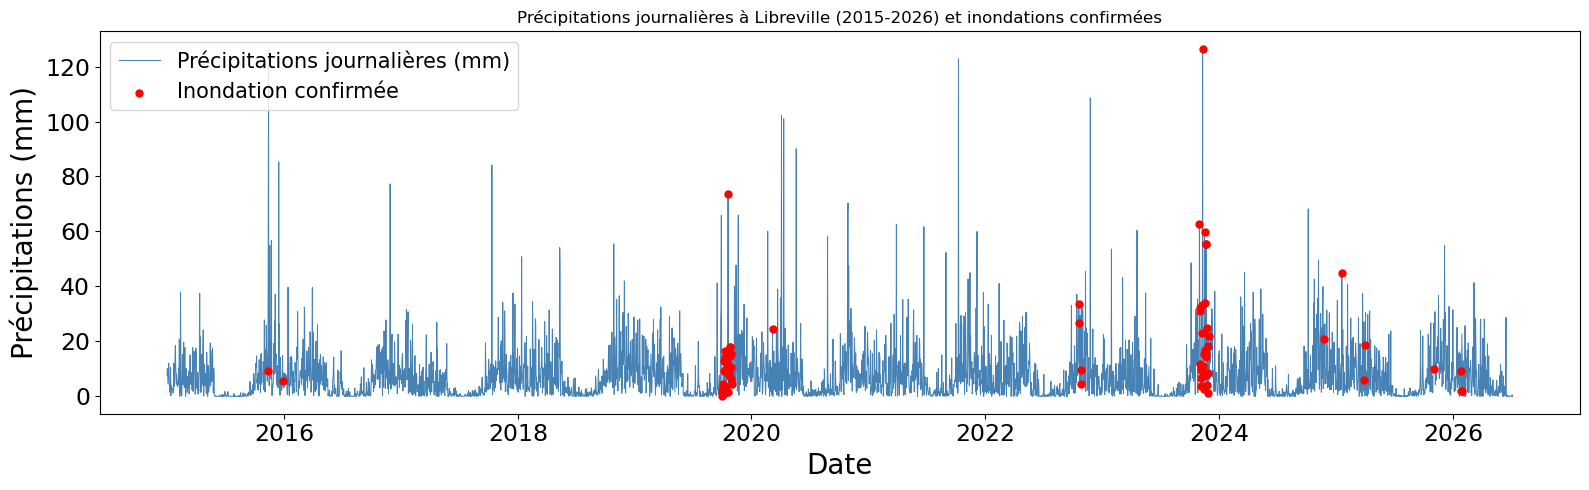

In [13]:
# Graphique 1 : évolution des précipitations journalières dans le temps
# Les jours d'inondation confirmée sont marqués par des points rouges

plt.figure(figsize=(16, 5))

# Courbe de fond : précipitations journalières sur toute la période
plt.plot(df["date"], df["precipitation_sum"], color="steelblue", linewidth=0.7,
         label="Précipitations journalières (mm)")

# Sélection des jours où une inondation réelle a été confirmée
jours_inondation = df[df["inondation_reelle"] == 1]

# Superposition de points rouges sur ces jours précis
plt.scatter(jours_inondation["date"], jours_inondation["precipitation_sum"],
            color="red", s=25, zorder=5, label="Inondation confirmée")

plt.title("Précipitations journalières à Libreville (2015-2026) et inondations confirmées")
plt.xlabel("Date", fontsize=20)
plt.ylabel("Précipitations (mm)", fontsize=20)
plt.legend(fontsize=15)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()
plt.savefig("figurePrecip.png")
plt.show()

## Distribution des précipitations

On observe ici la répartition statistique des précipitations journalières,
afin de mieux comprendre la fréquence des différents niveaux de pluie
(jours secs, pluies modérées, épisodes de pluies intenses).

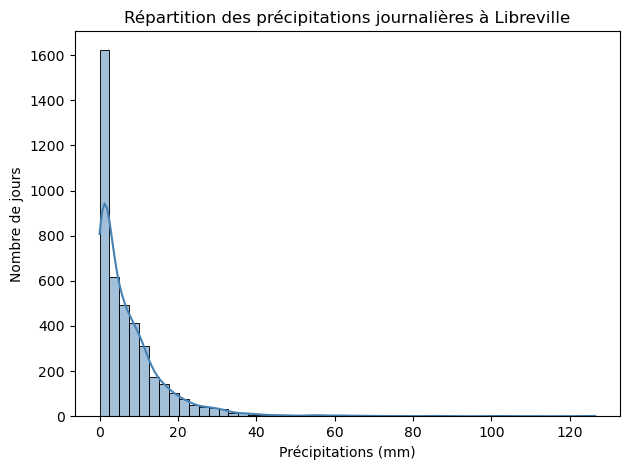

In [19]:
# Graphique 2 : histogramme de répartition des précipitations journalières
# Permet de voir si les fortes pluies (>50mm) sont rares ou fréquentes
import seaborn as sns
#plt.figure(figsize=(10, 5))
sns.histplot(df["precipitation_sum"], bins=50, color="steelblue",kde=True)

plt.title("Répartition des précipitations journalières à Libreville")
plt.xlabel("Précipitations (mm)")
plt.ylabel("Nombre de jours")
plt.tight_layout()
plt.show()

## Corrélations entre les variables

On visualise ici les corrélations entre toutes les variables météorologiques
et la variable cible (inondation réelle). Cela permet d'identifier
visuellement quelles variables sont les plus liées entre elles, et surtout
lesquelles semblent le plus associées au risque d'inondation.

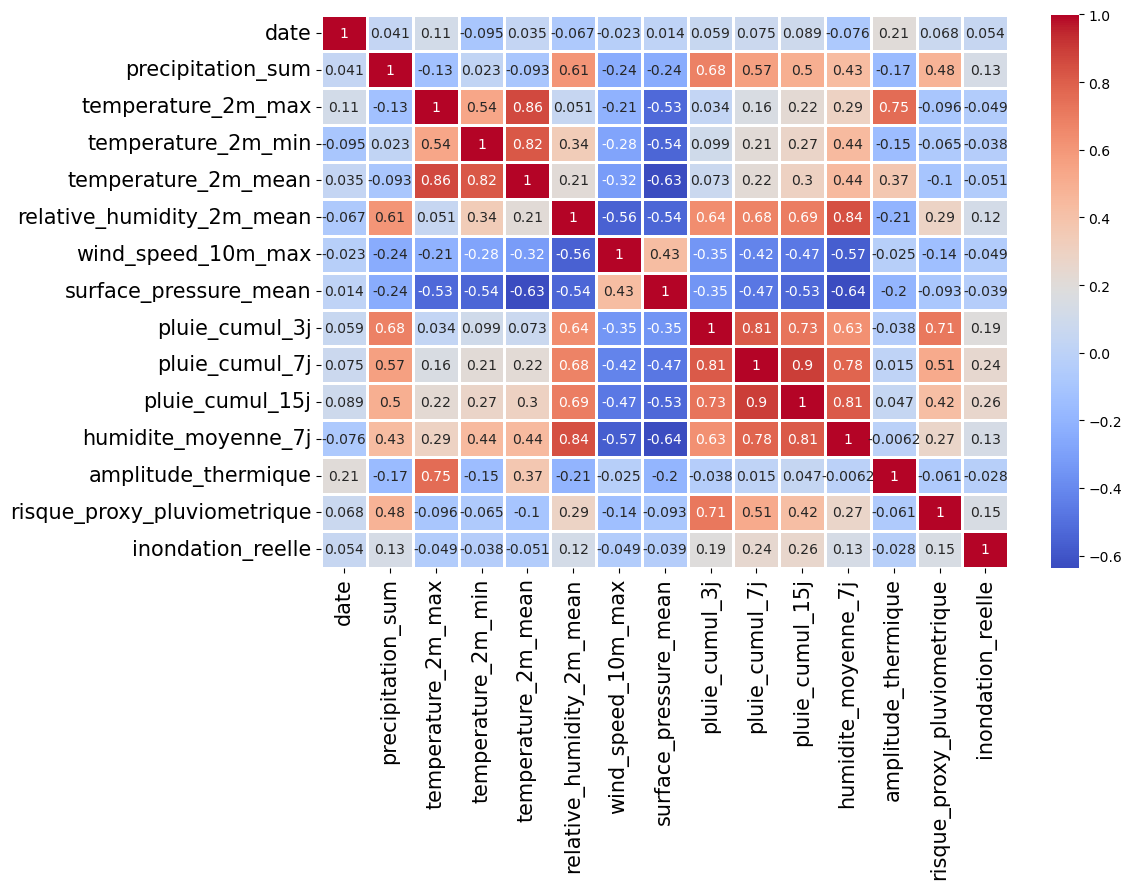


Corrélation de chaque variable avec 'inondation_reelle' :
inondation_reelle              1.000000
pluie_cumul_15j                0.256477
pluie_cumul_7j                 0.244016
pluie_cumul_3j                 0.193010
risque_proxy_pluviometrique    0.147801
precipitation_sum              0.133445
humidite_moyenne_7j            0.133340
relative_humidity_2m_mean      0.118948
date                           0.053636
amplitude_thermique           -0.028142
temperature_2m_min            -0.037648
surface_pressure_mean         -0.039077
wind_speed_10m_max            -0.048797
temperature_2m_max            -0.049177
temperature_2m_mean           -0.051110
Name: inondation_reelle, dtype: float64


In [23]:
# Graphique 3 : matrice de corrélation entre toutes les variables numériques
# Une valeur proche de 1 (rouge foncé) = forte corrélation positive
# Une valeur proche de -1 (bleu foncé) = forte corrélation négative
# Une valeur proche de 0 = pas de lien linéaire évident

import numpy as np

# On sélectionne uniquement les colonnes numériques (on exclut la date)
colonnes_numeriques = df.select_dtypes(include=[np.number])

# Calcul de la matrice de corrélation
correlation = df.corr()

plt.figure(figsize=(12, 9))
matrice_corre=sns.heatmap(correlation,annot=True, cmap='coolwarm',linewidths=0.9)
#plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
#plt.colorbar(label="Coefficient de corrélation")
#plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
#plt.yticks(range(len(correlation.columns)), correlation.columns)
#plt.title("Matrice de corrélation entre les variables")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

# Affichage textuel : corrélation de chaque variable avec la cible "inondation_reelle"
print("\nCorrélation de chaque variable avec 'inondation_reelle' :")
print(correlation["inondation_reelle"].sort_values(ascending=False))


#correlation = colonnes_numeriques.corr()

## ## Étape 5 : Préparation des données pour la modélisation

À partir de l'analyse précédente, on sélectionne les variables météorologiques
comme variables explicatives (X), et la variable `inondation_reelle` comme
variable cible à prédire (y). On sépare ensuite les données en deux
ensembles : un ensemble d'entraînement (utilisé pour que le modèle apprenne)
et un ensemble de test (utilisé pour évaluer honnêtement le modèle sur des
données qu'il n'a jamais vues).

In [12]:
# Sélection des variables explicatives (features) utilisées pour la prédiction
# On exclut la colonne "date" (non numérique) et "risque_proxy_pluviometrique"
# (car c'est un indicateur dérivé du même seuil de pluie, redondant avec
# les autres variables de précipitations)
colonnes_features = [
    "precipitation_sum",
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "pluie_cumul_3j",
    "pluie_cumul_7j",
    "pluie_cumul_15j",
    "humidite_moyenne_7j",
    "amplitude_thermique",
]

# X = variables d'entrée (ce que le modèle observe)
X = df[colonnes_features]

# y = variable cible (ce que le modèle doit apprendre à prédire)
y = df["inondation_reelle"]

print("Nombre de variables explicatives utilisées :", X.shape[1])
print("Nombre total d'observations :", X.shape[0])

Nombre de variables explicatives utilisées : 12
Nombre total d'observations : 4206


In [ ]:
## EXTRQIRE LES DONNES DE 2026 qnnee2026
df =df-qnnee2026 ,ne contiendrq 2015-2025

In [13]:
from sklearn.model_selection import train_test_split

# Découpage en ensemble d'entraînement (80%) et de test (20%)
# stratify=y garantit que la proportion de jours "inondation" est respectée
# de façon égale dans les deux ensembles (important vu leur rareté : 66/4206)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # garantit un résultat reproductible à chaque exécution
    stratify=y
)

print("Ensemble d'entraînement :", X_train.shape[0], "observations")
print("Ensemble de test :", X_test.shape[0], "observations")
print("\nNombre de cas 'inondation' dans l'entraînement :", y_train.sum())
print("Nombre de cas 'inondation' dans le test :", y_test.sum())

Ensemble d'entraînement : 3364 observations
Ensemble de test : 842 observations

Nombre de cas 'inondation' dans l'entraînement : 61
Nombre de cas 'inondation' dans le test : 15


## ## Étape 6 : Entraînement du modèle (Random Forest)

On utilise l'algorithme **Random Forest** (forêt aléatoire), qui construit
de nombreux arbres de décision et combine leurs résultats pour obtenir une
prédiction plus fiable. Ce modèle est bien adapté ici car :
- il fonctionne correctement même avec un nombre limité de données ;
- il permet d'identifier facilement les variables les plus influentes ;
- il gère le déséquilibre entre les classes grâce au paramètre
  `class_weight="balanced"`, qui donne plus d'importance aux rares cas
  d'inondation (66 sur 4206) pendant l'apprentissage.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Création du modèle Random Forest
modele = RandomForestClassifier(
    n_estimators=200,        # nombre d'arbres de décision dans la forêt
    class_weight="balanced", # compense le déséquilibre (peu de cas d'inondation)
    max_depth=8,              # profondeur maximale de chaque arbre (évite le sur-apprentissage)
    random_state=42           # garantit un résultat reproductible
)

# Entraînement du modèle sur les données d'entraînement uniquement
modele.fit(X_train, y_train)

print("Modèle entraîné avec succès ✅")

Modèle entraîné avec succès ✅


## ## Étape 7 : Évaluation du modèle

On évalue maintenant le modèle sur l'ensemble de test, c'est-à-dire sur des
données qu'il n'a **jamais vues** pendant l'entraînement. C'est la seule
façon d'évaluer honnêtement sa capacité à généraliser.

On utilise deux outils complémentaires :
- la **matrice de confusion**, qui résume les réussites et erreurs du modèle ;
- le **rapport de classification**, qui calcule des indicateurs de
  performance (precision, recall, F1-score) pour chaque classe.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# Le modèle prédit sur les données de test (jamais vues pendant l'entraînement)
y_pred = modele.predict(X_test)

# Matrice de confusion : tableau 2x2 résumant les prédictions
# Ligne 1 = vrais "pas d'inondation", Ligne 2 = vrais "inondation"
# Colonne 1 = prédit "pas d'inondation", Colonne 2 = prédit "inondation"
matrice = confusion_matrix(y_test, y_pred)
print("=== Matrice de confusion ===")
print(matrice)
print("\nLecture :")
print(f"Vrais négatifs (pas d'inondation, bien prédit)  : {matrice[0][0]}")
print(f"Faux positifs (fausse alerte)                    : {matrice[0][1]}")
print(f"Faux négatifs (inondation manquée -- grave)       : {matrice[1][0]}")
print(f"Vrais positifs (inondation bien détectée)         : {matrice[1][1]}")

# Rapport détaillé des performances
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=["Pas d'inondation", "Inondation"]))

=== Matrice de confusion ===
[[804  23]
 [ 10   5]]

Lecture :
Vrais négatifs (pas d'inondation, bien prédit)  : 804
Faux positifs (fausse alerte)                    : 23
Faux négatifs (inondation manquée -- grave)       : 10
Vrais positifs (inondation bien détectée)         : 5

=== Rapport de classification ===
                  precision    recall  f1-score   support

Pas d'inondation       0.99      0.97      0.98       827
      Inondation       0.18      0.33      0.23        15

        accuracy                           0.96       842
       macro avg       0.58      0.65      0.61       842
    weighted avg       0.97      0.96      0.97       842



In [18]:
import joblib

# Sauvegarde du modèle avec le chemin complet, pour éviter toute ambiguïté
chemin_modele = r"C:\Users\ADS\Desktop\Projet_Inondation\modele_random_forest_inondation.pkl"
joblib.dump(modele, chemin_modele)
print("Modèle sauvegardé avec succès ✅")
print(f"Emplacement : {chemin_modele}")

Modèle sauvegardé avec succès ✅
Emplacement : C:\Users\ADS\Desktop\Projet_Inondation\modele_random_forest_inondation.pkl


## Étape 8 : Comparaison de plusieurs algorithmes de Machine Learning

On compare ici trois algorithmes sur le même découpage entraînement/test
(pour une comparaison équitable) : Régression Logistique (modèle simple de
référence), Random Forest (déjà utilisé), et XGBoost.

Les modèles de type séquentiel (LSTM) ou convolutif (CNN), mentionnés dans
le sujet initial, ne sont pas testés à ce stade : ils nécessitent
généralement un volume de données nettement supérieur pour être entraînés
de façon fiable, ce qui n'est pas le cas ici (76 exemples positifs). Cette
piste est conservée comme perspective (section 4.4).

In [19]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.7 MB/s eta 0:00:42
    --------------------------------------- 1.3/69.5 MB 2.6 MB/s eta 0:00:26
   - -------------------------------------- 2.6/69.5 MB 3.9 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/69.5 MB 4.4 MB/s eta 0:00:16
   -- ------------------------------------- 3.9/69.5 MB 3.5 MB/s eta 0:00:19
   --- ------------------------------------ 6.3/69.5 MB 4.8 MB/s eta 0:00:14
   --- ------------------------------------ 6.3/69.5 MB 4.8 MB/s eta 0:00:14
   ---- ----------------------------------- 7.6/69.5 MB 4.2 MB/s eta 0:00:15
   ---- ----------------------------------- 8.7/69.5 MB 4.3 MB/s eta 0:00:15
   ----- ------------------

In [25]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Modèle 1 : Régression logistique (modèle de référence, simple et interprétable)
modele_logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
modele_logreg.fit(X_train, y_train)

# Modèle 2 : XGBoost
# scale_pos_weight compense le déséquilibre des classes (équivalent de class_weight)
poids_classe_positive = (y_train == 0).sum() / (y_train == 1).sum()
modele_xgboost = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    scale_pos_weight=poids_classe_positive,
    random_state=42,
    eval_metric="logloss"
)
modele_xgboost.fit(X_train, y_train)

print("Modèles entraînés avec succès ✅")
print(f"Poids appliqué à la classe 'inondation' pour XGBoost : {poids_classe_positive:.1f}")

C:\Users\ADS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Modèles entraînés avec succès ✅
Poids appliqué à la classe 'inondation' pour XGBoost : 54.1


### Correction : standardisation des variables pour la régression logistique

La régression logistique nécessite que les variables soient sur une échelle
comparable pour converger correctement. On applique donc une
standardisation (moyenne = 0, écart-type = 1), en ajustant le
standardiseur uniquement sur les données d'entraînement pour éviter toute
fuite d'information vers les données de test.

In [26]:
# On augmente max_iter et on change de solveur (liblinear est souvent plus stable
# pour des jeux de données de cette taille)
modele_logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    solver="liblinear",
    random_state=42
)
modele_logreg.fit(X_train_standardise, y_train)

print("Régression logistique réentraînée avec succès ✅")

Régression logistique réentraînée avec succès ✅


## Étape 9 : Évaluation comparative des trois modèles

On évalue les trois modèles sur le même ensemble de test, avec les mêmes
indicateurs que précédemment (matrice de confusion, precision, recall,
F1-score), afin de les comparer équitablement.

In [27]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Prédictions de chaque modèle sur l'ensemble de test
y_pred_logreg = modele_logreg.predict(X_test_standardise)
y_pred_rf = modele.predict(X_test)                # modèle Random Forest déjà entraîné
y_pred_xgb = modele_xgboost.predict(X_test)

# Fonction pour afficher un résumé compact des performances d'un modèle
def resumer_performance(nom_modele, y_reel, y_predit):
    matrice = confusion_matrix(y_reel, y_predit)
    rapport = classification_report(y_reel, y_predit, output_dict=True, target_names=["Pas d'inondation", "Inondation"])
    print(f"=== {nom_modele} ===")
    print(matrice)
    print(f"Precision (inondation) : {rapport['Inondation']['precision']:.2f}")
    print(f"Recall (inondation)    : {rapport['Inondation']['recall']:.2f}")
    print(f"F1-score (inondation)  : {rapport['Inondation']['f1-score']:.2f}")
    print()
    return rapport['Inondation']['f1-score']

f1_logreg = resumer_performance("Régression Logistique", y_test, y_pred_logreg)
f1_rf = resumer_performance("Random Forest", y_test, y_pred_rf)
f1_xgb = resumer_performance("XGBoost", y_test, y_pred_xgb)

# Tableau récapitulatif final
comparaison = pd.DataFrame({
    "Modèle": ["Régression Logistique", "Random Forest", "XGBoost"],
    "F1-score (Inondation)": [f1_logreg, f1_rf, f1_xgb]
}).sort_values("F1-score (Inondation)", ascending=False)

print("=== Classement final ===")
print(comparaison.to_string(index=False))

=== Régression Logistique ===
[[711 116]
 [  4  11]]
Precision (inondation) : 0.09
Recall (inondation)    : 0.73
F1-score (inondation)  : 0.15

=== Random Forest ===
[[804  23]
 [ 10   5]]
Precision (inondation) : 0.18
Recall (inondation)    : 0.33
F1-score (inondation)  : 0.23

=== XGBoost ===
[[821   6]
 [ 11   4]]
Precision (inondation) : 0.40
Recall (inondation)    : 0.27
F1-score (inondation)  : 0.32

=== Classement final ===
               Modèle  F1-score (Inondation)
              XGBoost               0.320000
        Random Forest               0.232558
Régression Logistique               0.154930



## Étape 3bis : Corrélation entre les variables explicatives elles-mêmes

En plus de la corrélation de chaque variable avec la cible (déjà réalisée),
on vérifie ici si certaines variables explicatives sont fortement corrélées
entre elles (multicolinéarité). Deux variables très corrélées apportent une
information redondante au modèle et peuvent être simplifiées.

In [25]:
# Corrélation entre toutes les variables explicatives (hors variable cible)
colonnes_features_only = [
    "precipitation_sum", "temperature_2m_max", "temperature_2m_min",
    "temperature_2m_mean", "relative_humidity_2m_mean", "wind_speed_10m_max",
    "surface_pressure_mean", "pluie_cumul_3j", "pluie_cumul_7j",
    "pluie_cumul_15j", "humidite_moyenne_7j", "amplitude_thermique",
]

correlation_features = df[colonnes_features_only].corr()

# On affiche uniquement les paires de variables fortement corrélées (> 0.8 ou < -0.8)
print("Paires de variables fortement corrélées entre elles (|corr| > 0.8) ")
paires_trouvees = False
for i in range(len(correlation_features.columns)):
    for j in range(i+1, len(correlation_features.columns)):
        valeur = correlation_features.iloc[i, j]
        if abs(valeur) > 0.8:
            print(f"{correlation_features.columns[i]}  <->  {correlation_features.columns[j]} : {valeur:.2f}")
            paires_trouvees = True

if not paires_trouvees:
    print("Aucune paire trouvée avec ce seuil.")

Paires de variables fortement corrélées entre elles (|corr| > 0.8) 
temperature_2m_max  <->  temperature_2m_mean : 0.86
temperature_2m_min  <->  temperature_2m_mean : 0.82
relative_humidity_2m_mean  <->  humidite_moyenne_7j : 0.84
pluie_cumul_3j  <->  pluie_cumul_7j : 0.81
pluie_cumul_7j  <->  pluie_cumul_15j : 0.90
pluie_cumul_15j  <->  humidite_moyenne_7j : 0.81


## Étape 3ter : Simplification des variables (réduction de la redondance)

Suite à l'analyse de corrélation entre variables explicatives, plusieurs
paires redondantes ont été identifiées (température max/min avec la
moyenne ; humidité lissée avec l'humidité brute et le cumul de pluie 15j ;
cumuls de pluie 3j/7j/15j se chevauchant). La liste des variables est donc
simplifiée pour ne conserver que l'information non redondante.

In [26]:
# Liste simplifiée des variables explicatives, après suppression des
# redondances identifiées par l'analyse de corrélation
colonnes_features = [
    "precipitation_sum",
    "temperature_2m_mean",
    "amplitude_thermique",
    "relative_humidity_2m_mean",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "pluie_cumul_3j",
    "pluie_cumul_15j",
]

print(f"Nombre de variables explicatives retenues : {len(colonnes_features)}")
print(colonnes_features)

Nombre de variables explicatives retenues : 8
['precipitation_sum', 'temperature_2m_mean', 'amplitude_thermique', 'relative_humidity_2m_mean', 'wind_speed_10m_max', 'surface_pressure_mean', 'pluie_cumul_3j', 'pluie_cumul_15j']


## Étape 4 : Séparation de l'année 2026 (test final "vie réelle")

Conformément aux recommandations de l'encadrant, l'année 2026 est mise de
côté avant toute étape de modélisation, afin de constituer un jeu de test
totalement indépendant représentant une situation réelle de prédiction sur
une période future jamais vue par le modèle. Cette approche est plus
rigoureuse que le découpage aléatoire 80/20 utilisé précédemment, qui
mélangeait des observations de toutes les années.

In [27]:
# Extraction de l'année 2026 : mise de côté, ne sera utilisée qu'à la toute
# fin, pour tester le modèle final sur une période jamais vue
annee_2026 = df[df["date"].dt.year == 2026].copy()

# Le nouveau df principal ne contient plus que 2015-2025 :
# c'est avec celui-ci que tout le travail de modélisation va être fait
df = df[df["date"].dt.year <= 2025].copy()

print(f"Nombre de jours dans le jeu principal (2015-2025) : {len(df)}")
print(f"Nombre de jours mis de côté pour le test final (2026) : {len(annee_2026)}")
print(f"\nRépartition inondation_reelle dans 2015-2025 :")
print(df['inondation_reelle'].value_counts())
print(f"\nRépartition inondation_reelle dans 2026 :")
print(annee_2026['inondation_reelle'].value_counts())

Nombre de jours dans le jeu principal (2015-2025) : 4018
Nombre de jours mis de côté pour le test final (2026) : 188

Répartition inondation_reelle dans 2015-2025 :
inondation_reelle
0    3945
1      73
Name: count, dtype: int64

Répartition inondation_reelle dans 2026 :
inondation_reelle
0    185
1      3
Name: count, dtype: int64


## Étape 5 : Préparation des données (X, y) et split entraînement/test

On reconstruit X et y à partir du nouveau df (2015-2025 uniquement) et de
la liste simplifiée de 8 variables. Le split 80/20 est également refait
sur cette base.

In [28]:
# X et y reconstruits sur le jeu principal 2015-2025, avec les 8 variables retenues
X = df[colonnes_features]
y = df["inondation_reelle"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille entraînement :", X_train.shape)
print("Taille test :", X_test.shape)
print("\nCas d'inondation dans l'entraînement :", y_train.sum())
print("Cas d'inondation dans le test :", y_test.sum())

Taille entraînement : (3214, 8)
Taille test : (804, 8)

Cas d'inondation dans l'entraînement : 58
Cas d'inondation dans le test : 15


## Étape 6 : Standardisation des variables

La Régression Logistique et le SVM nécessitent des variables sur une
échelle comparable pour fonctionner correctement (contrairement aux
modèles à base d'arbres, insensibles à l'échelle). On standardise donc les
données, en ajustant le standardiseur uniquement sur l'entraînement.

In [29]:
from sklearn.preprocessing import StandardScaler

standardiseur = StandardScaler()
X_train_standardise = standardiseur.fit_transform(X_train)
X_test_standardise = standardiseur.transform(X_test)

print("Standardisation effectuée ✅")

Standardisation effectuée ✅


## Étape 7 : Entraînement des cinq modèles de classification

Conformément aux recommandations de l'encadrant, cinq algorithmes sont
comparés : Régression Logistique, Arbre de Décision, Random Forest,
XGBoost et SVM. Pour chacun, le paramètre de pondération des classes est
activé lorsqu'il est disponible, afin de compenser le déséquilibre entre
les jours avec et sans inondation.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1. Régression Logistique (nécessite les données standardisées)
modele_logreg = LogisticRegression(class_weight="balanced", max_iter=5000, solver="liblinear", random_state=42)
modele_logreg.fit(X_train_standardise, y_train)

# 2. Arbre de Décision (nouveau, demandé par l'encadrant)
modele_arbre = DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=42)
modele_arbre.fit(X_train, y_train)

# 3. Random Forest
modele_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_depth=8, random_state=42)
modele_rf.fit(X_train, y_train)

# 4. XGBoost
poids_classe_positive = (y_train == 0).sum() / (y_train == 1).sum()
modele_xgb = XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=poids_classe_positive, random_state=42, eval_metric="logloss")
modele_xgb.fit(X_train, y_train)

# 5. SVM (nouveau, demandé par l'encadrant — nécessite les données standardisées)
modele_svm = SVC(class_weight="balanced", probability=True, random_state=42)
modele_svm.fit(X_train_standardise, y_train)

print("Les 5 modèles ont été entraînés avec succès ✅")

Les 5 modèles ont été entraînés avec succès ✅


## Étape 8 : Évaluation des cinq modèles

Chaque modèle est évalué sur le même ensemble de test (804 observations,
dont 15 cas réels d'inondation), à l'aide de quatre indicateurs
complémentaires :
- **Accuracy** : proportion totale de prédictions correctes (à interpréter
  avec prudence ici, vu le déséquilibre des classes) ;
- **Precision** : parmi les jours où le modèle a annoncé un risque, la
  proportion de vraies inondations ;
- **Recall** : parmi les vraies inondations, la proportion détectée par le
  modèle (l'indicateur le plus important pour un système d'alerte) ;
- **F1-score** : moyenne harmonique entre precision et recall.

La matrice de confusion complète est également affichée pour chaque
modèle, afin de visualiser précisément les faux positifs (fausses alertes)
et faux négatifs (inondations manquées).

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Prédictions de chaque modèle sur l'ensemble de test
y_pred_logreg = modele_logreg.predict(X_test_standardise)
y_pred_arbre  = modele_arbre.predict(X_test)
y_pred_rf     = modele_rf.predict(X_test)
y_pred_xgb    = modele_xgb.predict(X_test)
y_pred_svm    = modele_svm.predict(X_test_standardise)

modeles_predictions = {
    "Régression Logistique": y_pred_logreg,
    "Arbre de Décision": y_pred_arbre,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
}

resultats = []

for nom, y_pred in modeles_predictions.items():
    matrice = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"=== {nom} ===")
    print("Matrice de confusion :")
    print(matrice)
    print(f"Accuracy  : {acc:.2f}")
    print(f"Precision : {prec:.2f}")
    print(f"Recall    : {rec:.2f}")
    print(f"F1-score  : {f1:.2f}")
    print()

    resultats.append({"Modèle": nom, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

# Tableau récapitulatif final, trié par recall décroissant (priorité : détecter les inondations)
tableau_comparatif = pd.DataFrame(resultats).sort_values("Recall", ascending=False)
print("=== Tableau comparatif (trié par Recall décroissant) ===")
print(tableau_comparatif.to_string(index=False))

=== Régression Logistique ===
Matrice de confusion :
[[667 122]
 [  2  13]]
Accuracy  : 0.85
Precision : 0.10
Recall    : 0.87
F1-score  : 0.17

=== Arbre de Décision ===
Matrice de confusion :
[[706  83]
 [  5  10]]
Accuracy  : 0.89
Precision : 0.11
Recall    : 0.67
F1-score  : 0.19

=== Random Forest ===
Matrice de confusion :
[[767  22]
 [  8   7]]
Accuracy  : 0.96
Precision : 0.24
Recall    : 0.47
F1-score  : 0.32

=== XGBoost ===
Matrice de confusion :
[[782   7]
 [ 13   2]]
Accuracy  : 0.98
Precision : 0.22
Recall    : 0.13
F1-score  : 0.17

=== SVM ===
Matrice de confusion :
[[714  75]
 [  7   8]]
Accuracy  : 0.90
Precision : 0.10
Recall    : 0.53
F1-score  : 0.16

=== Tableau comparatif (trié par Recall décroissant) ===
               Modèle  Accuracy  Precision   Recall  F1-score
Régression Logistique  0.845771   0.096296 0.866667  0.173333
    Arbre de Décision  0.890547   0.107527 0.666667  0.185185
                  SVM  0.898010   0.096386 0.533333  0.163265
        Random

## Étape 9 : Sauvegarde du modèle retenu (Régression Logistique)

Le modèle de Régression Logistique est retenu comme modèle final, en
raison de son rappel (recall) nettement supérieur aux autres modèles,
critère jugé prioritaire dans un contexte d'alerte précoce où une
inondation manquée est plus coûteuse qu'une fausse alerte.

In [32]:
import joblib

# Sauvegarde du modèle retenu ET du standardiseur (indispensable : la
# Régression Logistique a besoin des données standardisées de la même
# façon qu'à l'entraînement)
joblib.dump(modele_logreg, r"C:\Users\ADS\Desktop\Projet_Inondation\modele_final_logreg.pkl")
joblib.dump(standardiseur, r"C:\Users\ADS\Desktop\Projet_Inondation\standardiseur.pkl")

print("Modèle et standardiseur sauvegardés avec succès ✅")

Modèle et standardiseur sauvegardés avec succès ✅


## Étape 10 : Test final du modèle sur l'année 2026 (données jamais vues)

Cette étape simule une situation réelle d'utilisation du modèle : on
recharge uniquement le modèle déjà entraîné et sauvegardé (sans refaire
le nettoyage, le split 80/20, ni le réentraînement), puis on l'applique
directement à des données d'une année complètement nouvelle (2026),
totalement absente de l'entraînement.

=== Performance du modèle sur l'année 2026 (jamais vue) ===
[[180   5]
 [  3   0]]
Accuracy  : 0.96
Precision : 0.00
Recall    : 0.00
F1-score  : 0.00


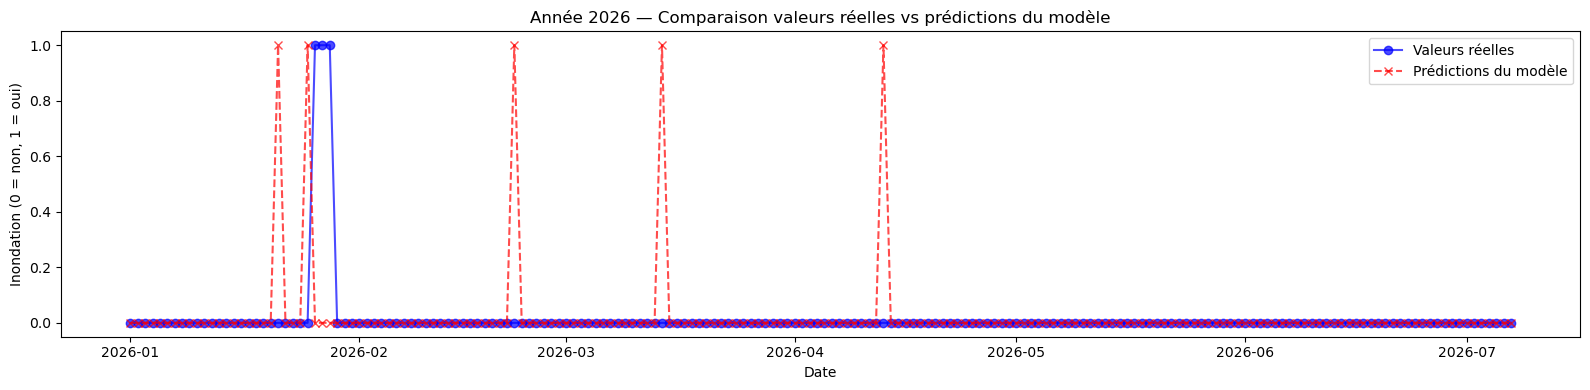

In [33]:
import joblib
import matplotlib.pyplot as plt

# Rechargement du modèle et du standardiseur sauvegardés (rien d'autre)
modele_final = joblib.load(r"C:\Users\ADS\Desktop\Projet_Inondation\modele_final_logreg.pkl")
standardiseur_final = joblib.load(r"C:\Users\ADS\Desktop\Projet_Inondation\standardiseur.pkl")

# Préparation des données 2026 : mêmes 8 variables, dans le même ordre
X_2026 = annee_2026[colonnes_features]
y_2026_reel = annee_2026["inondation_reelle"]

# Standardisation avec le MÊME standardiseur que celui entraîné sur 2015-2025
# (on ne le réajuste surtout pas ici, sinon la comparaison ne serait plus valide)
X_2026_standardise = standardiseur_final.transform(X_2026)

# Prédiction directe, sans aucun réentraînement
y_2026_predit = modele_final.predict(X_2026_standardise)

# --- Métriques de performance sur ce test final ---
acc_2026 = accuracy_score(y_2026_reel, y_2026_predit)
prec_2026 = precision_score(y_2026_reel, y_2026_predit, zero_division=0)
rec_2026 = recall_score(y_2026_reel, y_2026_predit, zero_division=0)
f1_2026 = f1_score(y_2026_reel, y_2026_predit, zero_division=0)

print("=== Performance du modèle sur l'année 2026 (jamais vue) ===")
print(confusion_matrix(y_2026_reel, y_2026_predit))
print(f"Accuracy  : {acc_2026:.2f}")
print(f"Precision : {prec_2026:.2f}")
print(f"Recall    : {rec_2026:.2f}")
print(f"F1-score  : {f1_2026:.2f}")

# --- Visualisation : valeurs réelles (bleu) vs prédictions (rouge), superposées dans le temps ---
plt.figure(figsize=(16, 4))
plt.plot(annee_2026["date"], y_2026_reel, color="blue", marker="o", linestyle="-", label="Valeurs réelles", alpha=0.7)
plt.plot(annee_2026["date"], y_2026_predit, color="red", marker="x", linestyle="--", label="Prédictions du modèle", alpha=0.7)
plt.title("Année 2026 — Comparaison valeurs réelles vs prédictions du modèle")
plt.xlabel("Date")
plt.ylabel("Inondation (0 = non, 1 = oui)")
plt.legend()
plt.tight_layout()
plt.show()

## Étape 11 : Évaluation avec tolérance temporelle (±2 jours)

Plutôt que d'exiger une correspondance exacte jour pour jour, on évalue ici
si le modèle détecte une inondation réelle dans une fenêtre de ±2 jours
autour de la date exacte. Cette approche est pertinente pour un système
d'alerte précoce, où une détection décalée de 1 à 2 jours reste utile,
contrairement à une évaluation strictement ponctuelle.

In [34]:
import numpy as np

# On travaille sur l'année 2026, avec les vraies valeurs et les prédictions
annee_2026 = annee_2026.reset_index(drop=True)
annee_2026["prediction"] = y_2026_predit

# Fenêtre de tolérance en jours
fenetre_tolerance = 2

# --- Recall tolérant : pour chaque vraie inondation, le modèle a-t-il
# prédit un risque dans les +/- 2 jours autour de cette date ? ---
dates_inondation_reelle = annee_2026.loc[annee_2026["inondation_reelle"] == 1, "date"]
dates_prediction_positive = annee_2026.loc[annee_2026["prediction"] == 1, "date"]

detections_tolerantes = 0
for date_reelle in dates_inondation_reelle:
    ecart_min = (dates_prediction_positive - date_reelle).abs().min()
    if pd.notna(ecart_min) and ecart_min <= pd.Timedelta(days=fenetre_tolerance):
        detections_tolerantes += 1

recall_tolerant = detections_tolerantes / len(dates_inondation_reelle)

print(f"Nombre de vraies inondations en 2026 : {len(dates_inondation_reelle)}")
print(f"Détections dans la fenêtre de ±{fenetre_tolerance} jours : {detections_tolerantes}")
print(f"Recall tolérant (±{fenetre_tolerance} jours) : {recall_tolerant:.1%}")

# --- Detail : pour chaque vraie inondation, l'écart en jours avec la
# prédiction positive la plus proche ---
print("\nDétail par événement réel :")
for date_reelle in dates_inondation_reelle:
    ecart_min = (dates_prediction_positive - date_reelle).abs().min()
    print(f"  {date_reelle.date()} → prédiction positive la plus proche à {ecart_min.days if pd.notna(ecart_min) else 'aucune'} jour(s)")

Nombre de vraies inondations en 2026 : 3
Détections dans la fenêtre de ±2 jours : 2
Recall tolérant (±2 jours) : 66.7%

Détail par événement réel :
  2026-01-26 → prédiction positive la plus proche à 1 jour(s)
  2026-01-27 → prédiction positive la plus proche à 2 jour(s)
  2026-01-28 → prédiction positive la plus proche à 3 jour(s)
